In [32]:
import pandas as pd

# Load all city datasets
bangalore = pd.read_csv("../Data/Bangalore.csv")
chennai = pd.read_csv("../Data/Chennai.csv")
delhi = pd.read_csv("../Data/Delhi.csv")
hyderabad = pd.read_csv("../Data/Hyderabad.csv")
kolkata = pd.read_csv("../Data/Kolkata.csv")
mumbai = pd.read_csv("../Data/Mumbai.csv")

# Add city column
bangalore["city"] = "Bangalore"
chennai["city"] = "Chennai"
delhi["city"] = "Delhi"
hyderabad["city"] = "Hyderabad"
kolkata["city"] = "Kolkata"
mumbai["city"] = "Mumbai"

# Combine all datasets
house_data = pd.concat([
    bangalore, chennai, delhi, hyderabad, kolkata, mumbai
], ignore_index=True)

print("Combined dataset ✅")
print(house_data.head())

Combined dataset ✅
      Price  Area                         Location  No. of Bedrooms  Resale  \
0  30000000  3340                 JP Nagar Phase 1                4       0   
1   7888000  1045       Dasarahalli on Tumkur Road                2       0   
2   4866000  1179  Kannur on Thanisandra Main Road                2       0   
3   8358000  1675                     Doddanekundi                3       0   
4   6845000  1670                          Kengeri                3       0   

   MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  \
0                 1          1             1                  1             1   
1                 0          1             1                  1             1   
2                 0          1             1                  1             1   
3                 0          0             0                  0             0   
4                 1          1             1                  1             1   

   ...  BED  Vaastu

In [33]:
print(house_data.columns)

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'city'],
      dtype='str')


In [34]:
# keep only important columns
house_clean = house_data[[
    "Price",
    "Area",
    "Location",
    "No. of Bedrooms",
    "city"
]]

# rename for simplicity
house_clean.columns = [
    "price",
    "area",
    "location",
    "bedrooms",
    "city"
]

print(house_clean.head())

      price  area                         location  bedrooms       city
0  30000000  3340                 JP Nagar Phase 1         4  Bangalore
1   7888000  1045       Dasarahalli on Tumkur Road         2  Bangalore
2   4866000  1179  Kannur on Thanisandra Main Road         2  Bangalore
3   8358000  1675                     Doddanekundi         3  Bangalore
4   6845000  1670                          Kengeri         3  Bangalore


In [35]:
city_to_district = {
    "Bangalore": "Bangalore",
    "Chennai": "Chennai",
    "Delhi": "New Delhi",
    "Hyderabad": "Hyderabad",
    "Kolkata": "Kolkata",
    "Mumbai": "Mumbai"
}

house_clean["district"] = house_clean["city"].map(city_to_district)

print(house_clean.head())

      price  area                         location  bedrooms       city  \
0  30000000  3340                 JP Nagar Phase 1         4  Bangalore   
1   7888000  1045       Dasarahalli on Tumkur Road         2  Bangalore   
2   4866000  1179  Kannur on Thanisandra Main Road         2  Bangalore   
3   8358000  1675                     Doddanekundi         3  Bangalore   
4   6845000  1670                          Kengeri         3  Bangalore   

    district  
0  Bangalore  
1  Bangalore  
2  Bangalore  
3  Bangalore  
4  Bangalore  


In [36]:
census = pd.read_csv("../Data/india-districts-census-2011.csv")

census_clean = census[[
    "State Name",
    "District name",
    "Population",
    "Literate",
    "Total_Power_Parity"
]]

# lowercase for matching
census_clean["District name"] = census_clean["District name"].str.lower()
house_clean["district"] = house_clean["district"].str.lower()

print(census_clean.head())

          State Name District name  Population  Literate  Total_Power_Parity
0  JAMMU AND KASHMIR       kupwara      870354    439654                1119
1  JAMMU AND KASHMIR        badgam      753745    335649                1066
2  JAMMU AND KASHMIR   leh(ladakh)      133487     93770                 242
3  JAMMU AND KASHMIR        kargil      140802     86236                 214
4  JAMMU AND KASHMIR         punch      476835    261724                 629


In [37]:
final_data = pd.merge(
    house_clean,
    census_clean,
    left_on="district",
    right_on="District name",
    how="inner"
)

print(final_data.head())

      price  area                         location  bedrooms       city  \
0  30000000  3340                 JP Nagar Phase 1         4  Bangalore   
1   7888000  1045       Dasarahalli on Tumkur Road         2  Bangalore   
2   4866000  1179  Kannur on Thanisandra Main Road         2  Bangalore   
3   8358000  1675                     Doddanekundi         3  Bangalore   
4   6845000  1670                          Kengeri         3  Bangalore   

    district State Name District name  Population  Literate  \
0  bangalore  KARNATAKA     bangalore     9621551   7512276   
1  bangalore  KARNATAKA     bangalore     9621551   7512276   
2  bangalore  KARNATAKA     bangalore     9621551   7512276   
3  bangalore  KARNATAKA     bangalore     9621551   7512276   
4  bangalore  KARNATAKA     bangalore     9621551   7512276   

   Total_Power_Parity  
0               20924  
1               20924  
2               20924  
3               20924  
4               20924  


In [38]:
print(final_data.head())
print(final_data.shape)

      price  area                         location  bedrooms       city  \
0  30000000  3340                 JP Nagar Phase 1         4  Bangalore   
1   7888000  1045       Dasarahalli on Tumkur Road         2  Bangalore   
2   4866000  1179  Kannur on Thanisandra Main Road         2  Bangalore   
3   8358000  1675                     Doddanekundi         3  Bangalore   
4   6845000  1670                          Kengeri         3  Bangalore   

    district State Name District name  Population  Literate  \
0  bangalore  KARNATAKA     bangalore     9621551   7512276   
1  bangalore  KARNATAKA     bangalore     9621551   7512276   
2  bangalore  KARNATAKA     bangalore     9621551   7512276   
3  bangalore  KARNATAKA     bangalore     9621551   7512276   
4  bangalore  KARNATAKA     bangalore     9621551   7512276   

   Total_Power_Parity  
0               20924  
1               20924  
2               20924  
3               20924  
4               20924  
(32963, 11)


In [39]:
print(final_data["city"].value_counts())

city
Mumbai       7719
Kolkata      6507
Bangalore    6207
Chennai      5014
Delhi        4998
Hyderabad    2518
Name: count, dtype: int64


In [40]:
# literacy rate
final_data["literacy_rate"] = final_data["Literate"] / final_data["Population"]

# price per sqft
final_data["price_per_sqft"] = final_data["price"] / final_data["area"]

print(final_data.head())

      price  area                         location  bedrooms       city  \
0  30000000  3340                 JP Nagar Phase 1         4  Bangalore   
1   7888000  1045       Dasarahalli on Tumkur Road         2  Bangalore   
2   4866000  1179  Kannur on Thanisandra Main Road         2  Bangalore   
3   8358000  1675                     Doddanekundi         3  Bangalore   
4   6845000  1670                          Kengeri         3  Bangalore   

    district State Name District name  Population  Literate  \
0  bangalore  KARNATAKA     bangalore     9621551   7512276   
1  bangalore  KARNATAKA     bangalore     9621551   7512276   
2  bangalore  KARNATAKA     bangalore     9621551   7512276   
3  bangalore  KARNATAKA     bangalore     9621551   7512276   
4  bangalore  KARNATAKA     bangalore     9621551   7512276   

   Total_Power_Parity  literacy_rate  price_per_sqft  
0               20924       0.780776     8982.035928  
1               20924       0.780776     7548.325359  
2    

In [41]:
print(final_data.groupby("city")["price"].mean())
print(final_data.groupby("city")["price_per_sqft"].mean())

city
Bangalore    1.058510e+07
Chennai      8.731264e+06
Delhi        1.588638e+07
Hyderabad    9.818380e+06
Kolkata      8.508570e+06
Mumbai       1.506165e+07
Name: price, dtype: float64
city
Bangalore     7073.571783
Chennai       7203.948158
Delhi        11601.343114
Hyderabad     5488.335077
Kolkata       6859.860029
Mumbai       16169.701661
Name: price_per_sqft, dtype: float64


In [42]:
import sys
!"{sys.executable}" -m pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


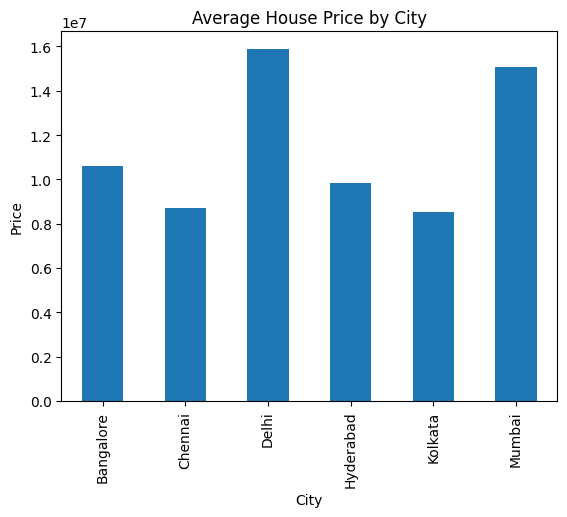

In [43]:
import matplotlib.pyplot as plt

final_data.groupby("city")["price"].mean().plot(kind="bar")

plt.title("Average House Price by City")
plt.xlabel("City")
plt.ylabel("Price")

plt.show()

In [44]:
import sys
!"{sys.executable}" -m pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = final_data[["area", "bedrooms", "Population", "literacy_rate"]]
y = final_data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# features
X = final_data[["area", "bedrooms", "Population", "literacy_rate"]]

# target
y = final_data["price"]

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [47]:
predictions = model.predict(X_test)

print("Sample predictions:")
print(predictions[:5])

Sample predictions:
[ 8442986.98151307 15145912.86344326 17606925.54902218 10599862.57821934
 10797253.2848317 ]


In [48]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)
print("R2 Score:", score)

R2 Score: 0.1321287224767429


In [49]:
final_data = pd.get_dummies(final_data, columns=["city"], drop_first=True)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = final_data.drop(columns=["price", "location", "district", "District name", "State Name"])
y = final_data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model retrained ✅")

Model retrained ✅


In [51]:
from sklearn.metrics import r2_score

predictions = model.predict(X_test)
print("New R2 Score:", r2_score(y_test, predictions))

New R2 Score: 0.6022802907605418


In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, predictions))

Random Forest R2: 0.9638439073978089


In [53]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.9957039011329734
Test Score: 0.9638439073978089


In [54]:
import joblib
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [55]:
final_data.to_csv("final_dataset.csv", index=False)

In [56]:
print(X.columns.tolist())

['area', 'bedrooms', 'Population', 'Literate', 'Total_Power_Parity', 'literacy_rate', 'price_per_sqft', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai']


In [57]:
import joblib

joblib.dump(model, "model.pkl")
print("Model saved ✅")

Model saved ✅
